In [1]:
import os
import multiprocessing

import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import pandas as pd

import torch
import torch.nn.functional as F

from src.utils.general import get_signal_to_noise_ratio

import random




def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(1)


blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'


blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


gray = '#C0C0C0'
purple = '#B05AA3'

gray_purple = LinearSegmentedColormap.from_list(
    "gray_purple",
    [gray , purple]
)


blue_distribution = '#00AEEF'
red_distribution = '#F15A2A'


os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
os.environ["NUMEXPR_NUM_THREADS"]="1"
os.environ["MKL_DYNAMIC"]="FALSE"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
multiprocessing.set_start_method("fork")


In [2]:
from src.model import SSCNetwork
from src.utils.episode_generation_protocol import make_input, LatentSpace
from src.utils.general import get_ordered_indices, test_network, get_cos_sim_torch
from src.utils.plotting import compare_distributions_12

from src.network_parameters import network_parameters

from Figure_4_utils import higher_order_selectivity

In [3]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_sensory", "mtl_semantic", "mtl", "ctx", "ctx_hat"]
recording_parameters["rate_activity"] = np.inf
recording_parameters["connections"] = ["ctx_mtl"]
recording_parameters["rate_connectivity"] = np.inf

input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 2


latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]
latent_specs["prob_list"] = [0. if i==j else 1/20 for i in range(5) for j in range(5)]

In [4]:
initial_network_path = "checkpoints/network_3_B.pt"

In [5]:
network = higher_order_selectivity('intact', 2, recording_parameters, input_params, latent_specs, initial_network_path, get_network=True)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050


In [6]:
#network.init_recordings(recording_parameters)
#torch.save(network, "checkpoints/network_5_no_semantics.pt")
network = torch.load("checkpoints/network_5_no_semantics.pt", weights_only=False)


def reset_ctx_indices_immature_local(net, ctx_indices):
    with torch.no_grad():
        net.ctx_IM[ctx_indices] = 1
        net.ctx_mtl[ctx_indices] = torch.randn((len(ctx_indices), net.mtl_size)) * net.ctx_mtl_std
        net.ctx_ctx[ctx_indices] = 0
        net.ctx_ctx[:, ctx_indices] = 0


present_episode_indices = []
assembly_size = 10
for i in range(latent_specs["dims"][0]):
    for j in range(latent_specs["dims"][1]):
        if i != j:
            episode_index = i * latent_specs["dims"][1] + j
            present_episode_indices.append(
                network.ordered_indices_ctx_episodes[
                    episode_index * assembly_size:(episode_index + 1) * assembly_size
                ]
            )

present_episode_indices = torch.cat(present_episode_indices)
remaining_subregion2_indices = network.ctx_subregions[1][
    ~torch.isin(network.ctx_subregions[1], present_episode_indices)
]
reset_ctx_indices_immature_local(network, remaining_subregion2_indices)
network.full_ordered_indices_ctx = torch.cat([
    network.ordered_indices_ctx[:100],
    network.ordered_indices_ctx_episodes[:250],
])

In [7]:
network.frozen = False
network.activity_recordings_rate = 1
network.connectivity_recordings_rate = 1

input_params["num_days"] = 1
input_params["latent_space"] = LatentSpace(**latent_specs)

input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)

0


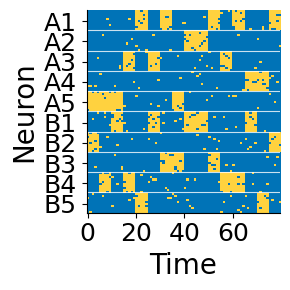

In [8]:
X_mtl_sensory_awake = torch.stack(network.activity_recordings["mtl_sensory"], dim=0)[network.awake_indices][:input_params["day_length"]]

fig = plt.figure(figsize=(3, 3))
plt.imshow(X_mtl_sensory_awake.T, cmap=blue_yellow, vmin=0, vmax=1, aspect='auto', interpolation='nearest')

labels_A = [f"A{i+1}" for i in range(5)]
labels_B = [f"B{i+1}" for i in range(5)]
labels = labels_A + labels_B


# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]


plt.yticks(positions, labels, fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Neuron", fontsize=20)
for boundary in range(10, 100, 10):
    plt.axhline(boundary - 0.5, color="white", linewidth=0.8, alpha=0.8)
sns.despine()
plt.tight_layout()
plt.savefig('Figures_SVG/7e1.svg', dpi=300, transparent=True)
plt.show()


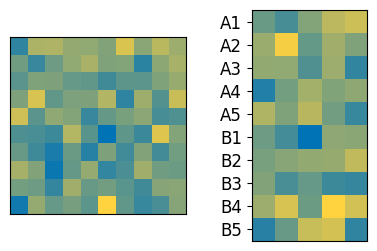

In [9]:
h_random = torch.randn(network.mtl_size)
mtl = h_random





fig, ax = plt.subplots(1, 2, figsize=(5, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]
ax[1].set_yticks(positions, labels, fontsize=12)

plt.savefig('Figures_SVG/6b1.svg', dpi=300, transparent=True)

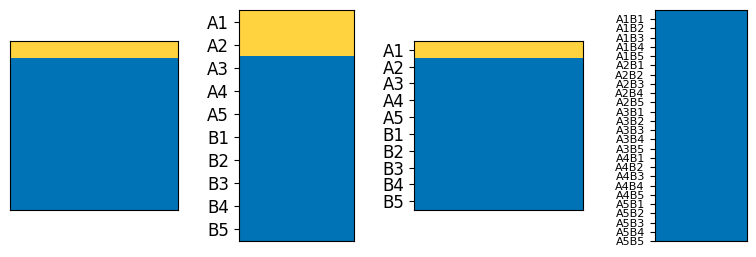

In [10]:
semantic_load = 1
mtl_sparsity = (semantic_load/network.max_semantic_load_input)*network.mtl_sparsity.clone()
mtl = network.pattern_complete('mtl', h_0=h_random, sparsity=mtl_sparsity)


ctx_hat = F.linear(mtl, network.ctx_mtl) + network.ctx_b*network.ctx_IM
ctx, _ = network.activation(ctx_hat, 'ctx', sleep=True, subregion_index=0)



fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)
ax[2].imshow(ctx[network.ordered_indices_ctx][:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes[:250]].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)




# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)

plt.savefig('Figures_SVG/6b2.svg', dpi=300, transparent=True)

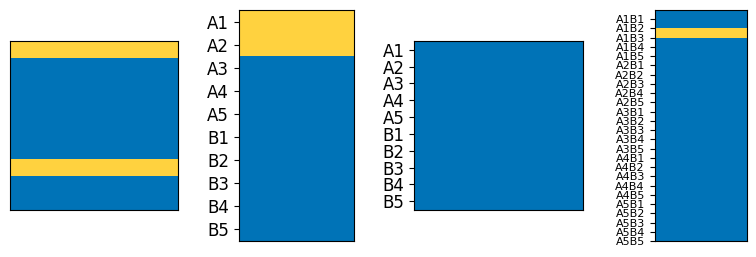

In [11]:
semantic_load = 2
mtl_sparsity = (semantic_load/network.max_semantic_load_input)*network.mtl_sparsity.clone()
mtl = network.pattern_complete('mtl', h_0=h_random, sparsity=mtl_sparsity)


ctx_hat = F.linear(mtl, network.ctx_mtl) + network.ctx_b*network.ctx_IM
ctx, _ = network.activation(ctx_hat, 'ctx', sleep=True, subregion_index=1)



fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)
ax[2].imshow(ctx[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes][:250].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)


plt.savefig('Figures_SVG/6b3.svg', dpi=300, transparent=True)

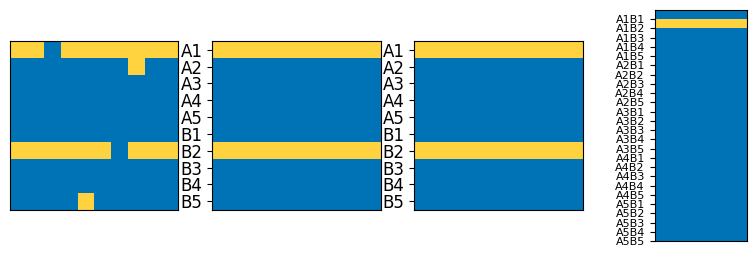

In [12]:
mtl = torch.stack(network.activity_recordings["mtl"], axis=0)[network.awake_indices][-1]
ctx = torch.stack(network.activity_recordings["ctx"], axis=0)[network.awake_indices][-1]


fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:100]].reshape((-1, 10)), cmap=blue_yellow)
ax[2].imshow(ctx[network.ordered_indices_ctx][:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes][:250].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)


plt.savefig('Figures_SVG/6c.svg', dpi=300, transparent=True)

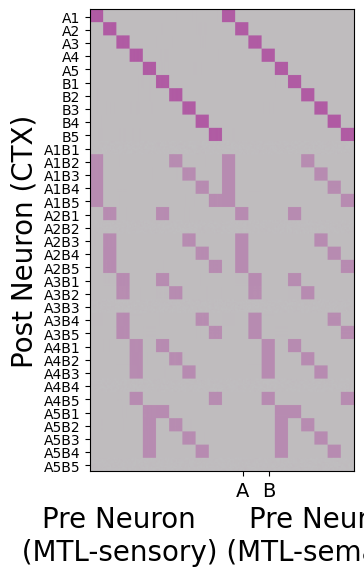

In [13]:
full_ordered_indices_ctx = torch.cat([
    network.ordered_indices_ctx[:100],
    network.ordered_indices_ctx_episodes[:250]
])


# Compute the full indexing array
full_ordered_indices = torch.cat([
    torch.arange(100),
    network.mtl_sensory_size + network.ordered_indices_mtl_semantic
])


fig = plt.figure(figsize=(5, 6))

plt.imshow(network.ctx_mtl[full_ordered_indices_ctx][:, full_ordered_indices], cmap=gray_purple)


# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]


# Example parameters
N = 250  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [100 + M * (k + 0.5) for k in range(NA * NB)]

positions.extend(positions_episodes)
labels.extend(labels_episodes)

plt.yticks(positions, labels)

plt.xticks([115, 135], ["A", "B"],  fontsize=14)
plt.xlabel("Pre Neuron      Pre Neuron\n  (MTL-sensory) (MTL-semantic)", fontsize=20)
plt.ylabel("Post Neuron (CTX)", fontsize=20)
plt.savefig('Figures_SVG/6d.svg', dpi=300, transparent=True)


(array([1800.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,   10.,  190.]),
 array([-1.05714166e-08,  1.00497867e-03,  2.00996804e-03,  3.01495730e-03,
         4.01994679e-03,  5.02493605e-03,  6.02992531e-03,  7.03491457e-03,
         8.03990383e-03,  9.04489309e-03,  1.00498823e-02,  1.10548716e-02,
         1.20598609e-02,  1.30648501e-02,  1.40698394e-02,  1.50748286e-02,
         1.60798188e-02,  1.70848072e-02,  1.80897973e-02,  1.90947857e-02,
         2.00997759e-02,  2.11047642e-02,  2.21097544e-02,  2.31147427e-02,
         2.41197329e-02,  2.51247212e-02,  2.61297114e-02,  2.71346997e-02,
         2.81396899e-02,  2.91446783e-02,  3.01496685e-02,  3.115465

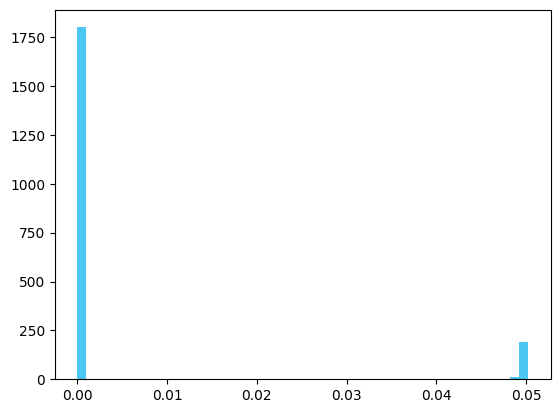

In [14]:
plt.hist(network.ctx_mtl[full_ordered_indices_ctx][:, full_ordered_indices][:10].flatten().cpu().numpy(), bins=50, color=blue_distribution, alpha=0.7, label="CTX-MTL Weights")

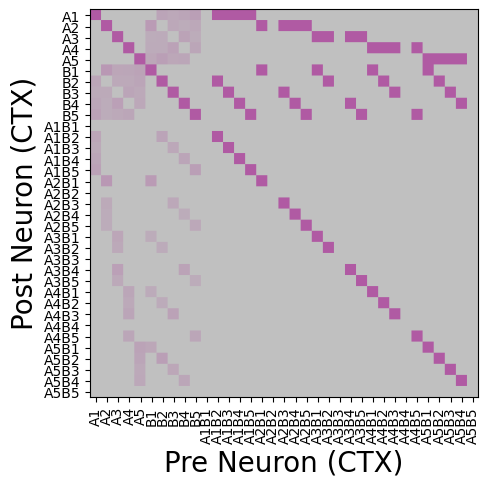

In [15]:

fig = plt.figure(figsize=(5, 6))


plt.imshow(network.ctx_ctx[full_ordered_indices_ctx][:, full_ordered_indices_ctx], cmap=gray_purple)


# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]


# Example parameters
N = 250  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [100 + M * (k + 0.5) for k in range(NA * NB)]

positions.extend(positions_episodes)
labels.extend(labels_episodes)

plt.yticks(positions, labels)
plt.xticks(positions, labels, rotation=90)


plt.xlabel("Pre Neuron (CTX)", fontsize=20)
plt.ylabel("Post Neuron (CTX)", fontsize=20)

plt.savefig('Figures_SVG/6e.svg', dpi=300, transparent=True)


In [16]:
from copy import deepcopy


def run_anterograde_association_test(
    network,
    latent_specs,
    input_params,
    recording_parameters,
    seed=None,
    pair_index=None,
    association_day_length=10,
    num_swaps_B=0,
    ctx_pattern_complete_iterations=10,
    assembly_size=10,
):

    def lesion_mtl_recurrent_local(net, disable_sleep_replay=False):
        with torch.no_grad():
            net.mtl_mtl.zero_()
            net.mtl_sensory_mtl_sensory.zero_()
            net.mtl_semantic_mtl_semantic.zero_()
        if disable_sleep_replay:
            net.sleep_duration_A = 0

    if seed is not None:
        seed_everything(seed)

    if pair_index is None:
        pair_index = int(torch.randint(latent_specs["dims"][0], (1,)).item())

    association_prob_list = [
        1.0 if (i == pair_index and j == pair_index) else 0.0
        for i in range(latent_specs["dims"][0])
        for j in range(latent_specs["dims"][1])
    ]

    association_input_params = dict(input_params)
    association_input_params["num_days"] = 1
    association_input_params["day_length"] = association_day_length

    association_latent_specs = dict(latent_specs)
    association_latent_specs["prob_list"] = association_prob_list
    association_input_params["latent_space"] = LatentSpace(**association_latent_specs)

    association_input, association_episodes, association_latents = make_input(**association_input_params)

    episode_pair_index = pair_index * latent_specs["dims"][1] + pair_index
    episode_ctx_indices = network.ordered_indices_ctx_episodes[
        episode_pair_index * assembly_size:(episode_pair_index + 1) * assembly_size
    ]

    sham = deepcopy(network)
    anterograde = deepcopy(network)

    def make_ctx_indices_immature_local(net, ctx_indices):
        with torch.no_grad():
            net.ctx_IM[ctx_indices] = 1
            net.ctx_mtl[ctx_indices] = torch.randn((len(ctx_indices), net.mtl_size)) * net.ctx_mtl_std
            net.ctx_ctx[ctx_indices] = 0
            net.ctx_ctx[:, ctx_indices] = 0

    for net_copy in [sham, anterograde]:
        make_ctx_indices_immature_local(net_copy, episode_ctx_indices)
        net_copy.frozen = False
        net_copy.init_recordings(recording_parameters)
        net_copy.activity_recordings_rate = 1
        net_copy.connectivity_recordings_rate = 1
        net_copy(association_input[0], debug=False)
        lesion_mtl_recurrent_local(net_copy, disable_sleep_replay=True) if net_copy is anterograde else None
        net_copy.sleep()

    def update_episode_indices_from_frozen_test_local(net):
        probe_recording_parameters = {
            "regions": ["ctx"],
            "rate_activity": 1,
            "connections": [],
            "rate_connectivity": np.inf,
        }
        probe_net = deepcopy(net)
        probe_net.frozen = True
        probe_net.init_recordings(probe_recording_parameters)
        with torch.no_grad():
            probe_net(association_input[0], debug=False)

        X_ctx_probe = torch.stack(probe_net.activity_recordings["ctx"], dim=0)[probe_net.awake_indices]
        subregion2 = probe_net.ctx_subregions[1]
        mean_subregion2_activity = X_ctx_probe[:, subregion2].float().mean(dim=0)
        top_local = torch.topk(mean_subregion2_activity, k=assembly_size).indices
        learned_episode_ctx_indices = subregion2[top_local]

        ordered_indices_ctx_episodes = net.ordered_indices_ctx_episodes.clone()
        ordered_indices_ctx_episodes[
            episode_pair_index * assembly_size:(episode_pair_index + 1) * assembly_size
        ] = learned_episode_ctx_indices
        net.ordered_indices_ctx_episodes = ordered_indices_ctx_episodes
        net.learned_episode_ctx_indices = learned_episode_ctx_indices
        net.full_ordered_indices_ctx = torch.cat([
            net.ordered_indices_ctx[:100],
            net.ordered_indices_ctx_episodes[:250],
        ])
        return learned_episode_ctx_indices

    sham_episode_ctx_indices = update_episode_indices_from_frozen_test_local(sham)
    anterograde_episode_ctx_indices = update_episode_indices_from_frozen_test_local(anterograde)


    b_offset = latent_specs["dims"][0] * assembly_size
    a_ctx_indices = sham.ordered_indices_ctx[pair_index * assembly_size:(pair_index + 1) * assembly_size]
    b_ctx_indices = sham.ordered_indices_ctx[b_offset + pair_index * assembly_size:b_offset + (pair_index + 1) * assembly_size]

    test_latent_space = LatentSpace(**latent_specs)
    a_size = latent_specs["total_sizes"][0]
    b_size = latent_specs["total_sizes"][1]
    a_pattern = test_latent_space.latent_patterns[0][pair_index]
    b_pattern = test_latent_space.latent_patterns[1][pair_index]

    def corrupt_b_pattern_local(pattern, num_swaps):
        x = pattern.clone().detach()
        if int(num_swaps) <= 0:
            return x
        on_index = pattern.nonzero().squeeze(1)
        off_index = (pattern == 0).nonzero().squeeze(1)
        flip_off = on_index[torch.randperm(len(on_index))[:int(num_swaps)]]
        flip_on = off_index[torch.randperm(len(off_index))[:int(num_swaps)]]
        x[flip_off] = 0
        x[flip_on] = 1
        return x

    corrupted_b_pattern = corrupt_b_pattern_local(b_pattern, num_swaps_B)
    sen_cue = torch.zeros(sham.sen_size)
    sen_cue[:a_size] = a_pattern
    sen_cue[a_size:a_size + b_size] = corrupted_b_pattern

    test_results = {}
    all_b_ctx_indices = sham.ordered_indices_ctx[
        b_offset:b_offset + latent_specs["dims"][1] * assembly_size
    ]
    other_b_ctx_indices = all_b_ctx_indices[~torch.isin(all_b_ctx_indices, b_ctx_indices)]

    for condition, net_eval in {"sham": sham, "anterograde": anterograde}.items():
        net_eval = deepcopy(net_eval)
        net_eval.frozen = True

        with torch.no_grad():


            mtl_sensory_hat = F.linear(sen_cue, net_eval.mtl_sensory_sen)
            mtl_sensory_cue, _ = net_eval.activation(mtl_sensory_hat, 'mtl_sensory')  

            mtl_state = torch.zeros(net_eval.mtl_size)
            mtl_state[:net_eval.mtl_sensory_size] = mtl_sensory_cue

            #plt.imshow(mtl_state.reshape((-1, 10)))

            ctx_hat = F.linear(mtl_state, net_eval.ctx_mtl) + net_eval.ctx_b * net_eval.ctx_IM
            ctx_state, _ = net_eval.activation(ctx_hat, 'ctx', subregion_index=0)

            #plt.imshow(ctx_state)

            mtl_semantic_hat = F.linear(ctx_state, net_eval.mtl_semantic_ctx) + net_eval.mtl_semantic_b * net_eval.mtl_semantic_IM
            mtl_semantic = net_eval.activation(mtl_semantic_hat, 'mtl_semantic')[0]
            mtl_state[net_eval.mtl_sensory_size:] = mtl_semantic

            #plt.imshow(mtl_state.reshape((-1, 10)))
            #plt.imshow(mtl_semantic[net_eval.ordered_indices_mtl_semantic].reshape((-1, 10)))

            ctx_hat = F.linear(mtl_state, net_eval.ctx_mtl) + net_eval.ctx_b * net_eval.ctx_IM
            ctx_state, _ = net_eval.activation(ctx_hat, 'ctx', subregion_index=0)

            if condition == "sham":
                plt.imshow(net_eval.ctx_mtl[net_eval.full_ordered_indices_ctx])
            #plt.imshow(ctx_hat[net_eval.full_ordered_indices_ctx].reshape((-1, 10)), cmap=blue_yellow)
            #plt.imshow(ctx_hat.reshape((-1, 10)), cmap=blue_yellow)
            #plt.imshow(ctx_hat.reshape((-1, 10)), cmap=blue_yellow)
            #if condition == "sham":
            #    plt.hist(ctx_hat.flatten())

            ctx_pc = net_eval.pattern_complete(
                'ctx',
                h_0=ctx_state,
                num_iterations=ctx_pattern_complete_iterations,
            )

            #plt.imshow(ctx_pc[net_eval.full_ordered_indices_ctx].reshape((-1, 10)), cmap=blue_yellow)

        test_results[condition] = {
            "ctx_state": ctx_state,
            "ctx_pc": ctx_pc,
            "target_ctx_mean": ctx_pc[b_ctx_indices].float().mean().item(),
            "cue_ctx_mean": ctx_pc[a_ctx_indices].float().mean().item(),
            "target_minus_other": ctx_pc[b_ctx_indices].float().mean().item() - ctx_pc[other_b_ctx_indices].float().mean().item(),
        }

    return {
        "seed": seed,
        "pair_index": pair_index,
        "association_day_length": association_day_length,
        "num_swaps_B": num_swaps_B,
        "a_ctx_indices": a_ctx_indices,
        "b_ctx_indices": b_ctx_indices,
        "sham": sham,
        "anterograde": anterograde,
        "sham_episode_ctx_indices": sham_episode_ctx_indices,
        "anterograde_episode_ctx_indices": anterograde_episode_ctx_indices,
        "test_results": test_results,
    }

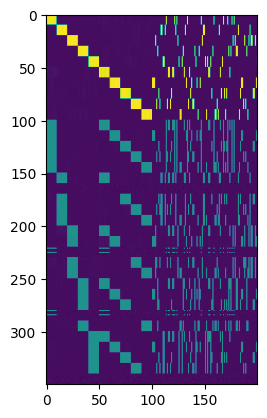

In [17]:
anterograde_test_params = {}
anterograde_test_params["num_seeds"] = 20
anterograde_test_params["pair_index"] = None
anterograde_test_params["association_day_length"] = 10
anterograde_test_params["num_swaps_B"] = 0
anterograde_test_params["ctx_pattern_complete_iterations"] = 10
anterograde_test_params["assembly_size"] = 10

anterograde_tests = {}
anterograde_summary = []

for seed in range(anterograde_test_params["num_seeds"]):
    seed = 1
    anterograde_test = run_anterograde_association_test(
        network,
        latent_specs,
        input_params,
        recording_parameters,
        seed=seed,
        pair_index=anterograde_test_params["pair_index"],
        association_day_length=anterograde_test_params["association_day_length"],
        num_swaps_B=anterograde_test_params["num_swaps_B"],
        ctx_pattern_complete_iterations=anterograde_test_params["ctx_pattern_complete_iterations"],
        assembly_size=anterograde_test_params["assembly_size"],
    )

    anterograde_tests[seed] = anterograde_test

    for condition in ["sham", "anterograde"]:
        anterograde_summary.append({
            "seed": seed,
            "pair_index": anterograde_test["pair_index"],
            "condition": condition,
            "target_ctx_mean": anterograde_test["test_results"][condition]["target_ctx_mean"],
            "cue_ctx_mean": anterograde_test["test_results"][condition]["cue_ctx_mean"],
            "target_minus_other": anterograde_test["test_results"][condition]["target_minus_other"],
        })

anterograde_summary_df = pd.DataFrame(anterograde_summary)
#display(anterograde_summary_df)
#display(anterograde_summary_df.pivot(index="seed", columns="condition", values="target_ctx_mean"))

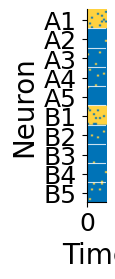

In [18]:
association_example = next(iter(anterograde_tests.values()))
association_plot_network = association_example["sham"]
association_day_length = association_example["association_day_length"]
X_mtl_sensory_association = torch.stack(association_plot_network.activity_recordings["mtl_sensory"], dim=0)[association_plot_network.awake_indices][:association_day_length]

fig = plt.figure(figsize=(2.5, 2.5))
plt.imshow(X_mtl_sensory_association.T, cmap=blue_yellow, vmin=0, vmax=1)

labels_A = [f"A{i+1}" for i in range(5)]
labels_B = [f"B{i+1}" for i in range(5)]
labels = labels_A + labels_B



# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]
plt.yticks(positions, labels, fontsize=18)
plt.xticks([0], fontsize=18)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Neuron", fontsize=20)
for boundary in range(10, 100, 10):
    plt.axhline(boundary - 0.5, color="white", linewidth=0.8, alpha=0.8)
sns.despine()
plt.savefig('Figures_SVG/7e2.svg', dpi=300, transparent=True)
plt.show()


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


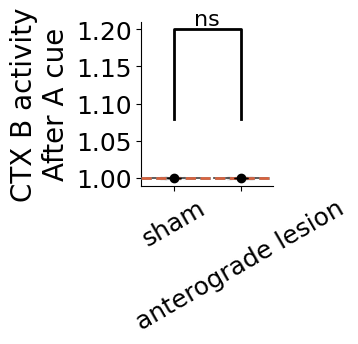

In [19]:
dist1 = (
    "sham",
    anterograde_summary_df[anterograde_summary_df["condition"] == "sham"]["target_ctx_mean"].tolist(),
)

dist2 = (
    "anterograde lesion",
    anterograde_summary_df[anterograde_summary_df["condition"] == "anterograde"]["target_ctx_mean"].tolist(),
)


blue = '#00AEEF'
red = '#F15A2A'

palette = {
    "sham": blue,
    "anterograde lesion": red,
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("CTX B activity\nAfter A cue", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks(fontsize=18)
plt.tight_layout()
sns.despine()

In [20]:
association_sweep_params = {}
association_sweep_params["num_seeds"] = 20
association_sweep_params["num_cpu"] = 8
association_sweep_params["association_day_length"] = 10
association_sweep_params["num_swaps_B_values"] = range(1, 11)
association_sweep_params["pair_index"] = None
association_sweep_params["ctx_pattern_complete_iterations"] = 10
association_sweep_params["assembly_size"] = 10

association_sweep_network = network
association_sweep_latent_specs = latent_specs
association_sweep_input_params = input_params
association_sweep_recording_parameters = recording_parameters


def run_anterograde_association_noise_point(seed, num_swaps_B):
    anterograde_test = run_anterograde_association_test(
        association_sweep_network,
        association_sweep_latent_specs,
        association_sweep_input_params,
        association_sweep_recording_parameters,
        seed=seed,
        pair_index=association_sweep_params["pair_index"],
        association_day_length=association_sweep_params["association_day_length"],
        num_swaps_B=num_swaps_B,
        ctx_pattern_complete_iterations=association_sweep_params["ctx_pattern_complete_iterations"],
        assembly_size=association_sweep_params["assembly_size"],
    )

    return {
        "seed": seed,
        "pair_index": anterograde_test["pair_index"],
        "num_swaps_B": num_swaps_B,
        "sham_target_ctx_mean": anterograde_test["test_results"]["sham"]["target_ctx_mean"],
        "anterograde_target_ctx_mean": anterograde_test["test_results"]["anterograde"]["target_ctx_mean"],
    }


experiment_params = [
    (seed, num_swaps_B)
    for num_swaps_B in association_sweep_params["num_swaps_B_values"]
    for seed in range(association_sweep_params["num_seeds"])
]

with multiprocessing.Pool(processes=association_sweep_params["num_cpu"]) as pool:
    association_sweep_results = pool.starmap(
        run_anterograde_association_noise_point,
        experiment_params,
    )


,seed,pair_index,num_swaps_B,sham_target_ctx_mean,anterograde_target_ctx_mean
0,0,4,1,1.0,1.0
1,1,0,1,1.0,1.0
2,2,3,1,1.0,1.0
3,3,1,1,1.0,0.0
4,4,0,1,1.0,1.0
...,...,...,...,...,...
195,15,2,10,0.0,0.0
196,16,1,10,0.0,0.0
197,17,4,10,0.0,0.0
198,18,1,10,0.0,0.0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


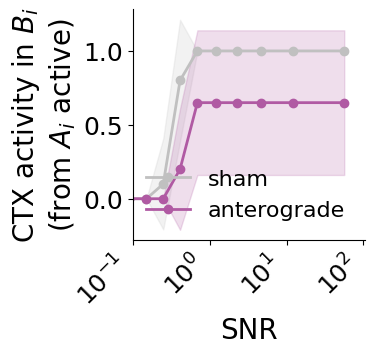

In [22]:
association_sweep_df = pd.DataFrame(association_sweep_results)
display(association_sweep_df)

association_summary = (
    association_sweep_df.groupby("num_swaps_B")
    .agg(
        sham_target_ctx_mean_mean=("sham_target_ctx_mean", "mean"),
        sham_target_ctx_mean_std=("sham_target_ctx_mean", "std"),
        anterograde_target_ctx_mean_mean=("anterograde_target_ctx_mean", "mean"),
        anterograde_target_ctx_mean_std=("anterograde_target_ctx_mean", "std"),
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

x_num_swaps = association_summary["num_swaps_B"].values
x_snr = np.array([
    float(get_signal_to_noise_ratio(int(num_swaps), network, region="mtl_sensory"))
    for num_swaps in x_num_swaps
], dtype=float)
finite_mask = np.isfinite(x_snr) & (x_snr > 0)
x = x_snr[finite_mask]

sham_mean = association_summary["sham_target_ctx_mean_mean"].values[finite_mask]
sham_std = association_summary["sham_target_ctx_mean_std"].fillna(0).values[finite_mask]
anterograde_mean = association_summary["anterograde_target_ctx_mean_mean"].values[finite_mask]
anterograde_std = association_summary["anterograde_target_ctx_mean_std"].fillna(0).values[finite_mask]

ax.plot(x, sham_mean, marker='o', color=gray, linewidth=2, label='sham')
ax.fill_between(x, sham_mean - sham_std, sham_mean + sham_std, color=gray, alpha=0.2)

ax.plot(x, anterograde_mean, marker='o', color=purple, linewidth=2, label='anterograde')
ax.fill_between(x, anterograde_mean - anterograde_std, anterograde_mean + anterograde_std, color=purple, alpha=0.2)

ax.set_xlabel('SNR', fontsize=20)
ax.set_ylabel(r"CTX activity in $B_i$" + '\n(from $A_i$ active)', fontsize=20)
ax.set_xscale("log")
shared_lower = max(float(np.min(x)) * 0.95, 1e-1)
shared_upper = max(float(np.max(x)), 1e2) * 1.05
decade_ticks = np.array([1e-1, 1e0, 1e1, 1e2], dtype=float)
decade_ticks = decade_ticks[(decade_ticks >= shared_lower) & (decade_ticks <= shared_upper)]
decade_formatter = mticker.FuncFormatter(lambda val, pos: rf"$10^{{{int(np.round(np.log10(val)))}}}$" if val > 0 else "")
ax.set_xlim(shared_lower, shared_upper)
ax.xaxis.set_major_locator(mticker.FixedLocator(decade_ticks))
ax.xaxis.set_major_formatter(decade_formatter)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.tick_params(labelsize=18)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(frameon=False, fontsize=16, loc='lower right')
sns.despine()


plt.savefig('Figures_SVG/7e3.svg', dpi=300, transparent=True)
 

